# Misspecification stress test

The [baseline](01_baseline_sensitivity.ipynb), [complexity](02_complexity_robustness_tradeoff.ipynb), and [reference-dataset-construction](03_reference_dataset_construction.ipynb) notebooks all hold the DGP correctly specified: recovery after re-default is drawn from the same distribution as first-default recovery. This notebook breaks that assumption on purpose and asks research goal 3's question directly: does the re-default-aware formula's advantage survive when the data is generated under an assumption it doesn't know about?

[`derivation.md`'s "Re-default-aware model" section](../docs/derivation.md#re-default-aware-model) names this the one load-bearing assumption of the re-default-aware formula's derivation: the formula has a single $RR$ term, no separate slot for a re-default recovery rate, so there's no way to accommodate a mismatch by construction. Recovery after re-default is drawn from a distribution with a lower mean than first-default recovery and compared against the same $P_{rd}$ sweep used in the [baseline notebook](01_baseline_sensitivity.ipynb), so the results are directly comparable to the correctly specified case.

Naive estimation is used for the main comparison, matching the [baseline](01_baseline_sensitivity.ipynb) and [complexity](02_complexity_robustness_tradeoff.ipynb) notebooks, so only the DGP itself varies. A second section revisits the same misspecification under both naive and compliant estimation, to check whether it compounds with the residual bias the [reference-dataset-construction notebook](03_reference_dataset_construction.ipynb) found.

In [1]:
import numpy as np

from lgd_sim.dgp import DGPParams
from lgd_sim.experiment import run_adjustment_comparison, run_baseline, run_merge_compliance
from lgd_sim.metrics import summarize
from lgd_sim.plotting import plot_adjustment_comparison, plot_regime_comparison

SEED = 42
N_EXPOSURES = 10_000
N_REPLICATIONS = 1_000
PC = 0.2
RESULTS_DIR = "../results"

## Recovery-after-re-default misspecification

Correctly specified: $RR_{ard} \sim \text{Beta}(0.3, 0.3)$, the same distribution as first-default recovery $RR$. Misspecified: $RR_{ard} \sim \text{Beta}(0.15, 0.4)$, a lower mean. Both panels sweep $P_{rd}$ at $PC=0.2$, the same sweep as the [baseline notebook](01_baseline_sensitivity.ipynb)'s Sweep 1, with naive estimation throughout.

In [2]:
prd_values = np.arange(0.0, 0.51, 0.05).round(2)

correct_recovery_params = DGPParams(pc=PC, prd=0.1)
misspecified_recovery_params = DGPParams(
    pc=PC, prd=0.1, rr_after_redefault_alpha=0.15, rr_after_redefault_beta=0.4
)

correct_recovery_results = run_baseline(
    sweep_param="prd",
    sweep_values=prd_values,
    base_params=correct_recovery_params,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)
misspecified_recovery_results = run_baseline(
    sweep_param="prd",
    sweep_values=prd_values,
    base_params=misspecified_recovery_params,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)

correct_recovery_summary = summarize(correct_recovery_results, sweep_param="prd")
misspecified_recovery_summary = summarize(misspecified_recovery_results, sweep_param="prd")
correct_recovery_summary.to_csv(f"{RESULTS_DIR}/misspec_recovery_correct_summary.csv", index=False)
misspecified_recovery_summary.to_csv(
    f"{RESULTS_DIR}/misspec_recovery_misspecified_summary.csv", index=False
)

error_mean_columns = ["prd"] + [
    f"{f}_error_mean" for f in ["lgd_basic", "lgd_lgc", "lgd_prd", "lgd_new"]
]
misspecified_recovery_summary[error_mean_columns]

,prd,lgd_basic_error_mean,lgd_lgc_error_mean,lgd_prd_error_mean,lgd_new_error_mean
0,0.00,0.000066,0.000066,0.000066,0.000066
1,0.05,-0.001284,0.007932,0.008708,0.002685
2,0.10,-0.002474,0.015538,0.017384,0.005431
3,0.15,-0.004220,0.022303,0.025499,0.007669
4,0.20,-0.005925,0.028932,0.033890,0.010033
5,0.25,-0.007537,0.035185,0.042011,0.012448
6,0.30,-0.009392,0.041015,0.050078,0.014609
7,0.35,-0.011320,0.046309,0.057902,0.016721
8,0.40,-0.013446,0.051221,0.065398,0.018626
9,0.45,-0.015530,0.055989,0.073077,0.020612


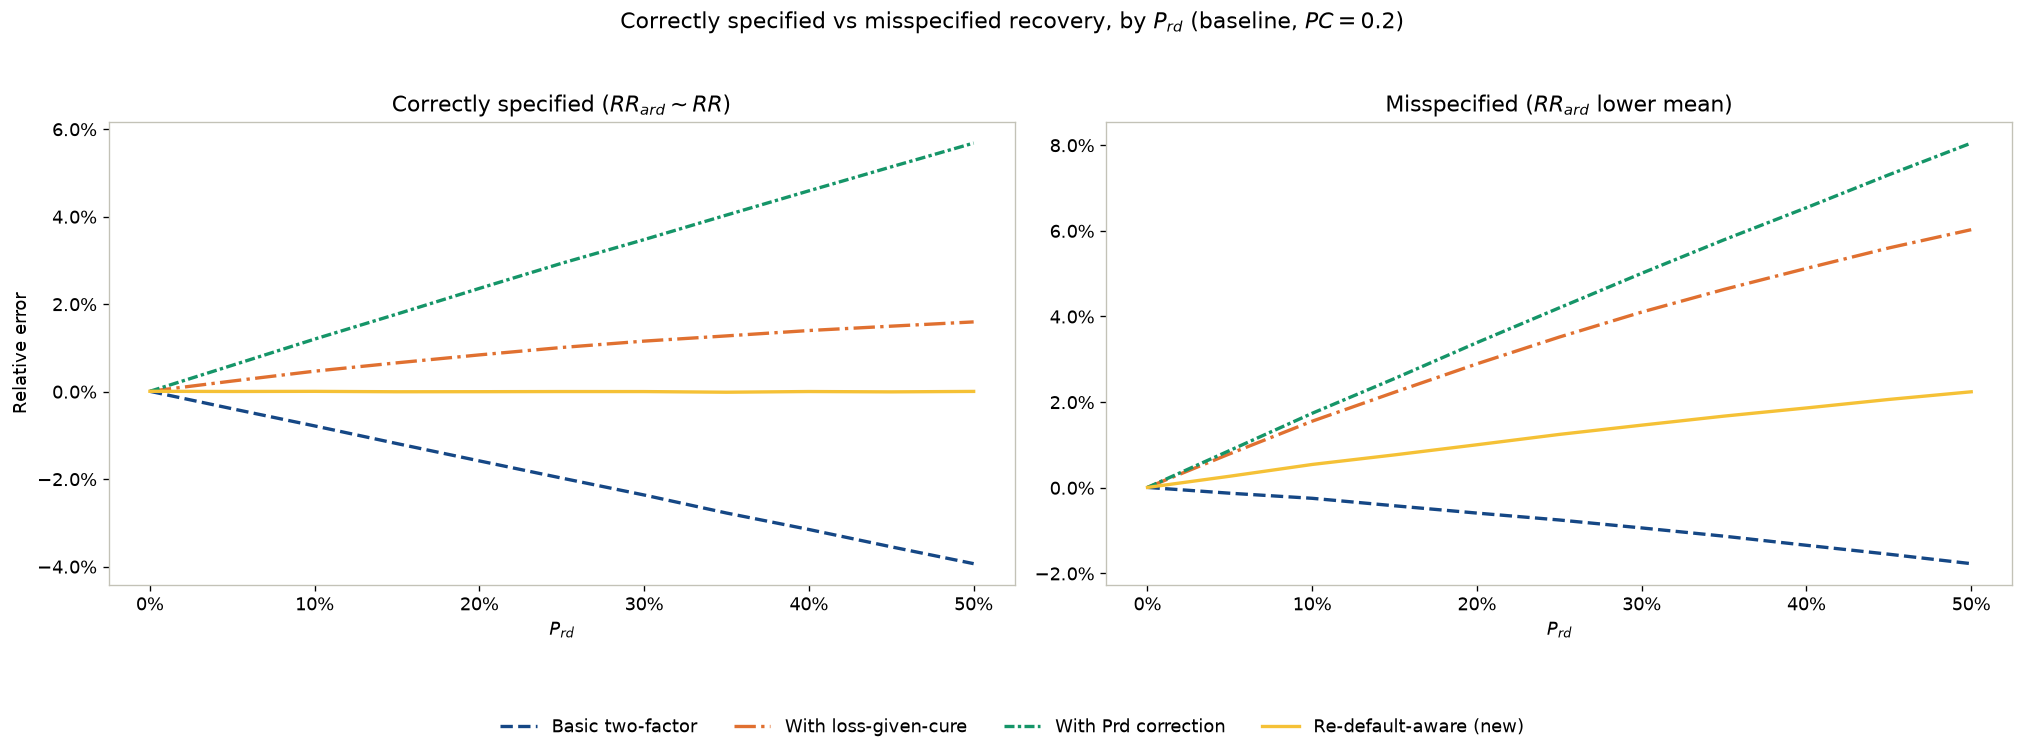

In [3]:
fig = plot_regime_comparison(
    correct_recovery_summary,
    misspecified_recovery_summary,
    sweep_param="prd",
    x_label="$P_{rd}$",
    title="Correctly specified vs misspecified recovery, by $P_{rd}$ (baseline, $PC=0.2$)",
    left_title="Correctly specified ($RR_{ard} \\sim RR$)",
    right_title="Misspecified ($RR_{ard}$ lower mean)",
)
fig.savefig(f"{RESULTS_DIR}/misspec_recovery_comparison.png", bbox_inches="tight")

Under correct specification, the re-default-aware formula's bias stays at noise level across the whole $P_{rd}$ range, matching the [baseline notebook](01_baseline_sensitivity.ipynb) exactly (same seed, same DGP). Under misspecification, its bias grows steadily with $P_{rd}$, from essentially 0% to +0.54% at $P_{rd}=0.1$ to +2.24% at $P_{rd}=0.5$.

This is a reversal of the formula's advantage, and it happens almost immediately. Comparing bias magnitudes rather than direction: at every $P_{rd}$ from 0.05 upward, the re-default-aware formula's misspecified bias is larger than the basic formula's. At $P_{rd}=0.5$, the re-default-aware formula is off by 2.24% while the basic formula, the one it was built to improve on, is off by only 1.77%. The more sophisticated formula becomes the worse one under this specific misspecification, because the assumption it violates is exactly the one [`derivation.md`](../docs/derivation.md#re-default-aware-model) names as load-bearing: the same recovery rate applying to a first default and to a redefaulted exposure's fresh loss. The basic formula's own bias actually shrinks in magnitude here (from -3.93% to -1.77% at $P_{rd}=0.5$) rather than growing, since its pooled recovery estimate partially absorbs the lower $RR_{ard}$ too, pulling its prediction and the now-lower $LGD_{true}$ in the same direction.

## Does the recovery misspecification interact with the merge rule?

The [reference-dataset-construction notebook](03_reference_dataset_construction.ipynb) found that compliant estimation leaves a small residual bias in the re-default-aware formula, because a merged exposure's compound recovery gets pooled with a genuine first default's plain recovery draw, and the two happened to share the same underlying distribution. If $RR_{ard}$ is now also misspecified, that pooled distribution no longer matches $RR$ for a second, independent reason. This section reruns the merge-fraction sweep from the [reference-dataset-construction notebook](03_reference_dataset_construction.ipynb), but under the misspecified recovery distribution, to see whether the two effects compound.

In [4]:
mean_cure_month_values = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 55.0, 60.0, 70.0, 80.0]
misspecified_merge_params = DGPParams(
    pc=PC, prd=0.1, rr_after_redefault_alpha=0.15, rr_after_redefault_beta=0.4
)

interaction_results = run_merge_compliance(
    sweep_param="mean_cure_month",
    sweep_values=mean_cure_month_values,
    base_params=misspecified_merge_params,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)

interaction_merge_fraction = (
    interaction_results[interaction_results["regime"] == "naive"]
    .groupby("mean_cure_month")
    .apply(lambda g: g["n_merged"].sum() / g["n_redefault"].sum(), include_groups=False)
    .rename("merge_fraction")
    .reset_index()
)

interaction_naive_summary = summarize(
    interaction_results[interaction_results["regime"] == "naive"], sweep_param="mean_cure_month"
)
interaction_compliant_summary = summarize(
    interaction_results[interaction_results["regime"] == "compliant"],
    sweep_param="mean_cure_month",
)
interaction_naive_summary = interaction_naive_summary.merge(
    interaction_merge_fraction, on="mean_cure_month"
)
interaction_compliant_summary = interaction_compliant_summary.merge(
    interaction_merge_fraction, on="mean_cure_month"
)
interaction_naive_summary.to_csv(
    f"{RESULTS_DIR}/misspec_interaction_naive_summary.csv", index=False
)
interaction_compliant_summary.to_csv(
    f"{RESULTS_DIR}/misspec_interaction_compliant_summary.csv", index=False
)

interaction_columns = ["mean_cure_month", "merge_fraction", "lgd_new_error_mean"]
print("naive:")
print(interaction_naive_summary[interaction_columns].to_string(index=False))
print("compliant:")
print(interaction_compliant_summary[interaction_columns].to_string(index=False))

naive:
 mean_cure_month  merge_fraction  lgd_new_error_mean
             1.0        0.152469            0.004907
             5.0        0.163562            0.005260
            10.0        0.179101            0.005829
            20.0        0.228790            0.006708
            30.0        0.312697            0.007573
            40.0        0.498477            0.008582
            50.0        0.802374            0.009490
            55.0        0.913012            0.009793
            60.0        0.970391            0.010030
            70.0        0.998372            0.010259
            80.0        0.999950            0.010353
compliant:
 mean_cure_month  merge_fraction  lgd_new_error_mean
             1.0        0.152469            0.004843
             5.0        0.163562            0.005086
            10.0        0.179101            0.005476
            20.0        0.228790            0.005843
            30.0        0.312697            0.005814
            40.0        0.49

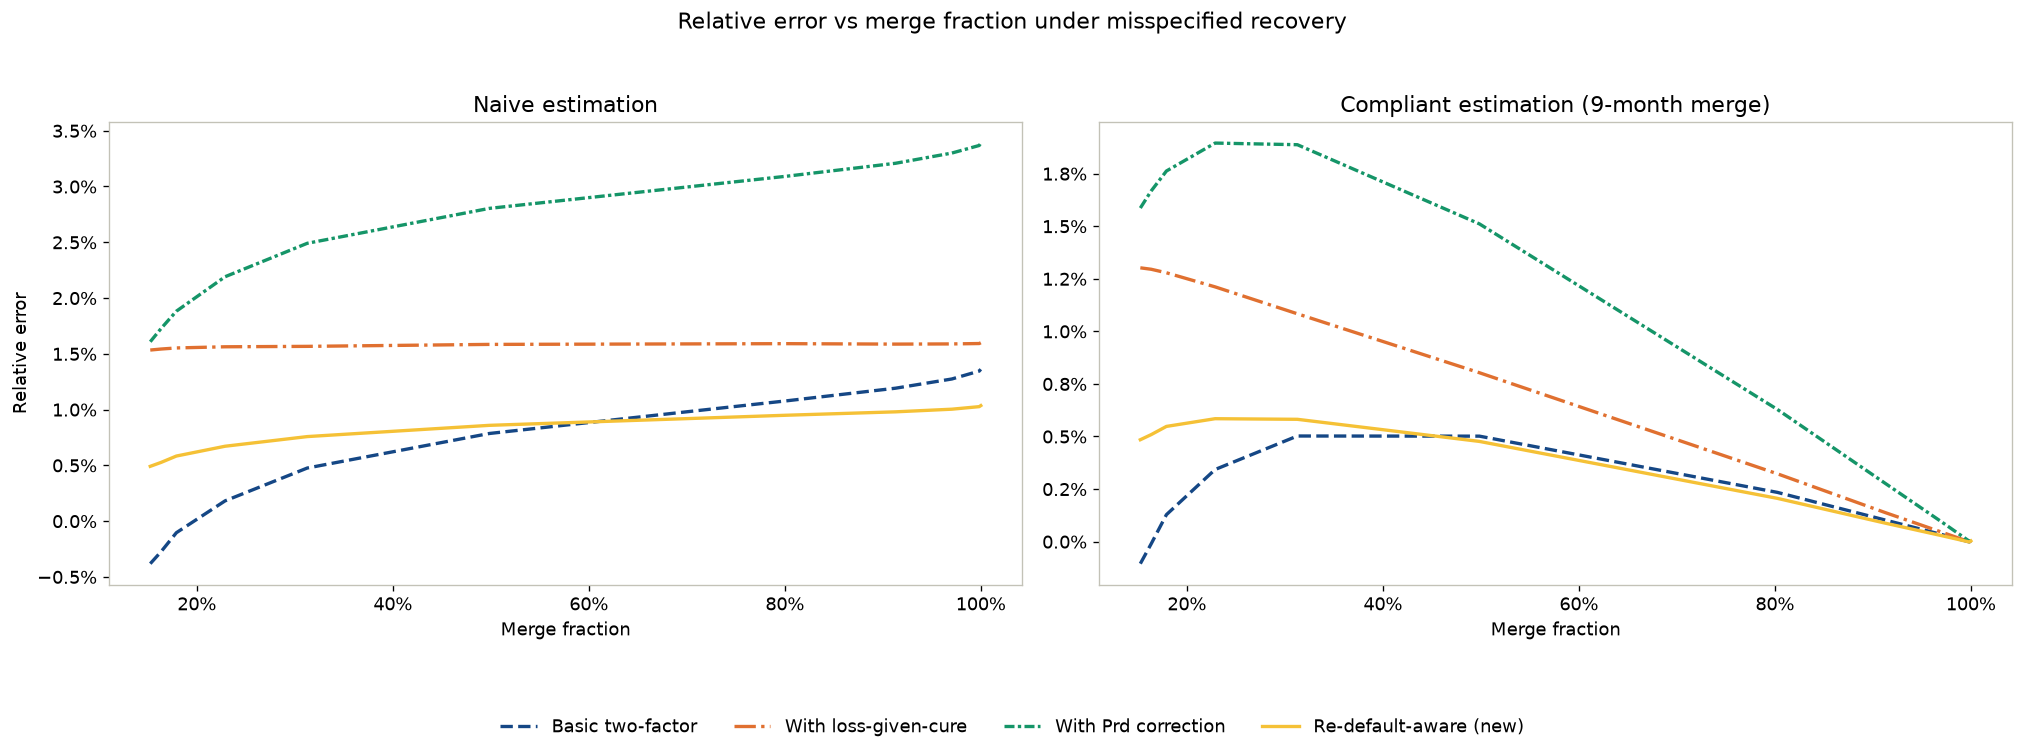

In [5]:
fig = plot_regime_comparison(
    interaction_naive_summary,
    interaction_compliant_summary,
    sweep_param="merge_fraction",
    x_label="Merge fraction",
    title="Relative error vs merge fraction under misspecified recovery",
    left_title="Naive estimation",
    right_title="Compliant estimation (9-month merge)",
)
fig.savefig(f"{RESULTS_DIR}/misspec_interaction_comparison.png", bbox_inches="tight")

Under naive estimation, misspecified recovery adds a bias that grows with the merge fraction, from +0.49% at a 15% merge fraction to +1.04% once nearly every re-default merges, the same growing-with-elapsed-time shape the [reference-dataset-construction notebook](03_reference_dataset_construction.ipynb) found under correct specification, just uniformly worse. Compliant estimation does not track that same growth. It stays close to naive at low merge fractions (+0.48% at 15%), rises a little further to a shallow peak of about +0.58% around a 23-31% merge fraction, then reverses and falls toward zero as the merge fraction keeps climbing, landing under 0.01% once merging is essentially universal.

That fall-off is the same mechanism the [reference-dataset-construction notebook](03_reference_dataset_construction.ipynb) identified for the residual compliant-regime bias under correct specification: at a high merge fraction, the compound recovery credited to a merged exposure is dominated by $RR_{brd}$, the elapsed-time-dependent pre-re-default recovery, not by $RR_{ard}$, the distribution this section's misspecification actually changes. Once almost every re-default is being merged, the misspecified draw barely enters the pooled recovery estimate at all, so compliance's protective effect against the merge-rule mismatch survives the recovery misspecification intact rather than compounding with it.

## A fix: segmenting $RR$ from $RR_{ard}$

The reversal above traces back to the re-default-aware formula's one $RR$ term: the derivation assumes the same recovery rate applies to a first default and to a redefaulted exposure's fresh loss ([`derivation.md`, "Re-default-aware model"](../docs/derivation.md#re-default-aware-model)), so no re-estimation trick fixes a violation of that assumption, only a variant with a second, separate rate for the redefault-loss term can. [`derivation.md`'s "A segmented variant: relaxing the shared-recovery assumption"](../docs/derivation.md#a-segmented-variant-relaxing-the-shared-recovery-assumption) derives that variant, $LGD_{adj}$, and checks it collapses back to $LGD_{new}$, $LGD_{Prd}$, and the basic formula at the same boundary cases the other three formulas already satisfy. [`dgp_assumptions.md`'s "Estimating formula inputs from the simulated data"](../docs/dgp_assumptions.md#estimating-formula-inputs-from-the-simulated-data) covers the calibration side: why the existing pooled $RR$ estimate is contaminated once $RR_{ard} \neq RR$, and why an independent re-default, still logged as its own default observation, needs its own calibration pool rather than a share of the first-default one.

In [6]:
adjustment_merge_results = run_adjustment_comparison(
    sweep_param="mean_cure_month",
    sweep_values=mean_cure_month_values,
    base_params=misspecified_recovery_params,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)

adjustment_merge_summaries = {}
for regime in ("naive", "compliant"):
    regime_summary = (
        adjustment_merge_results[adjustment_merge_results["regime"] == regime]
        .groupby("mean_cure_month")[["lgd_new_error", "lgd_new_adj_error"]]
        .mean()
        .add_suffix("_mean")
        .reset_index()
        .merge(interaction_merge_fraction, on="mean_cure_month")
    )
    regime_summary.to_csv(
        f"{RESULTS_DIR}/misspec_adjustment_merge_{regime}_summary.csv", index=False
    )
    adjustment_merge_summaries[regime] = regime_summary

adjustment_merge_summaries["compliant"]

,mean_cure_month,lgd_new_error_mean,lgd_new_adj_error_mean,merge_fraction
0,1.0,0.004843,0.000009,0.152469
1,5.0,0.005086,-0.000008,0.163562
2,10.0,0.005476,0.000101,0.179101
3,20.0,0.005843,0.000029,0.228790
4,30.0,0.005814,-0.000035,0.312697
5,40.0,0.004762,0.000013,0.498477
6,50.0,0.002056,0.000055,0.802374
7,55.0,0.000871,-0.000054,0.913012
8,60.0,0.000279,-0.000032,0.970391
9,70.0,-0.000019,-0.000037,0.998372


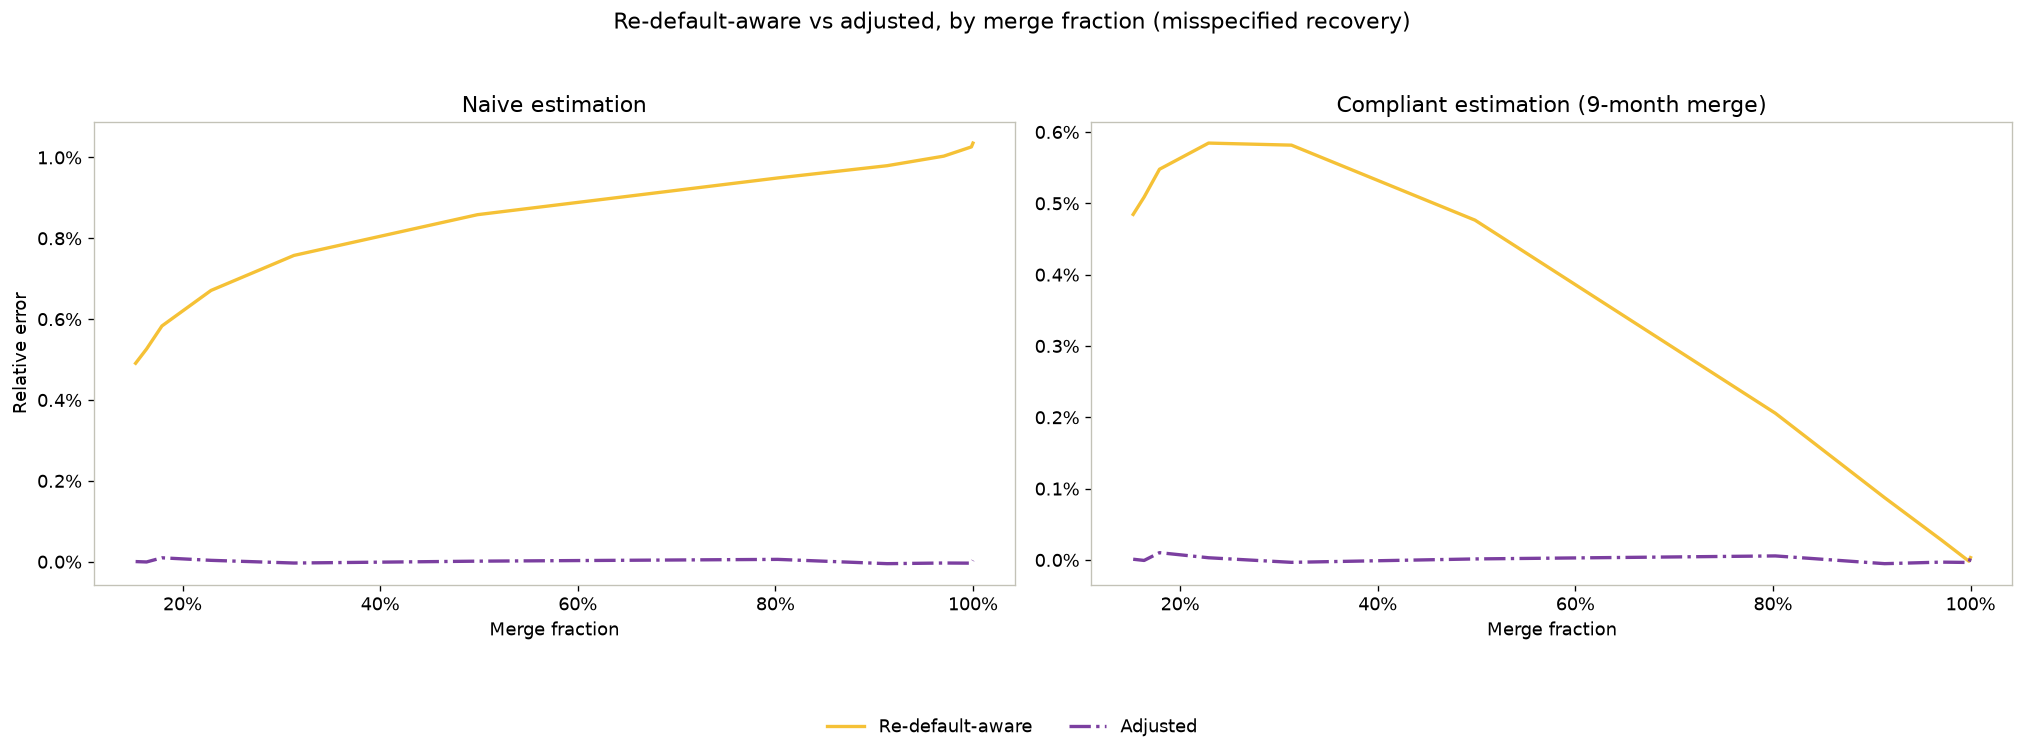

In [7]:
fig = plot_adjustment_comparison(
    adjustment_merge_summaries["naive"],
    adjustment_merge_summaries["compliant"],
    sweep_param="merge_fraction",
    x_label="Merge fraction",
    title="Re-default-aware vs adjusted, by merge fraction (misspecified recovery)",
)
fig.savefig(f"{RESULTS_DIR}/misspec_adjustment_merge_comparison.png", bbox_inches="tight")

The adjusted formula's bias stays at noise level across the full merge-fraction range, under both naive and compliant estimation, while the re-default-aware formula's bias keeps growing under naive estimation (to +1.04% once merging is essentially universal).

Under compliant estimation, the re-default-aware formula's own bias behaves differently, the same protective mechanism the merge-rule section above found: it falls toward zero as the merge fraction grows, since a merged exposure's compound recovery joins its pooled estimate of $RR$. The adjusted formula stays flat throughout for the same reason, applied to its own homogeneous-sample estimate of $RR$: that estimate credits a merged exposure's compound recovery too, so nothing about how the reference dataset handles merging leaves any of its bias exposed.

### Does the fix hold at smaller portfolio sizes?

The independent-redefault pool the segmented variant's $RR_{ard}$ estimate draws from shrinks as the merge fraction grows, since fewer re-defaults are left unmerged to populate it. A small portfolio shrinks that pool further still. This section sweeps portfolio size at the same stress configuration used above ($P_{rd}=0.3$, mean cure month 40, about a 50% merge fraction), under misspecified recovery, to check whether the segmented variant's unbiasedness holds up or degrades as $n$ falls.

In [8]:
from lgd_sim.experiment import run_adjustment_complexity_sweep
from lgd_sim.plotting import plot_adjustment_bias_variance_decomposition

N_EXPOSURES_VALUES = [100, 200, 500, 1000, 2000, 5000, 10_000]
STRESS_PARAMS = DGPParams(
    pc=PC,
    prd=0.3,
    mean_cure_month=40.0,
    rr_after_redefault_alpha=0.15,
    rr_after_redefault_beta=0.4,
)

adjustment_complexity_results = run_adjustment_complexity_sweep(
    n_exposures_values=N_EXPOSURES_VALUES,
    base_params=STRESS_PARAMS,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)

stat_suffix = {"mean": "mean", "std": "sd"}
adjustment_complexity_summaries = {}
for regime in ("naive", "compliant"):
    regime_results = adjustment_complexity_results[
        adjustment_complexity_results["regime"] == regime
    ]
    regime_summary = regime_results.groupby("n_exposures")[
        ["lgd_new_error", "lgd_new_adj_error"]
    ].agg(["mean", "std"])
    regime_summary.columns = [
        f"{column}_{stat_suffix[stat]}" for column, stat in regime_summary.columns
    ]
    regime_summary = regime_summary.reset_index()
    regime_summary.to_csv(
        f"{RESULTS_DIR}/misspec_adjustment_complexity_{regime}_summary.csv", index=False
    )
    adjustment_complexity_summaries[regime] = regime_summary

adjustment_complexity_summaries["compliant"]

,n_exposures,lgd_new_error_mean,lgd_new_error_sd,lgd_new_adj_error_mean,lgd_new_adj_error_sd
0,100,0.015064,0.025479,0.000842,0.020002
1,200,0.014345,0.017834,-0.000133,0.014062
2,500,0.014487,0.011339,0.000302,0.008919
3,1000,0.014019,0.007664,0.000086,0.006020
4,2000,0.014120,0.005611,0.000045,0.004333
5,5000,0.014144,0.003490,-0.000041,0.002703
6,10000,0.014171,0.002450,0.000083,0.001896


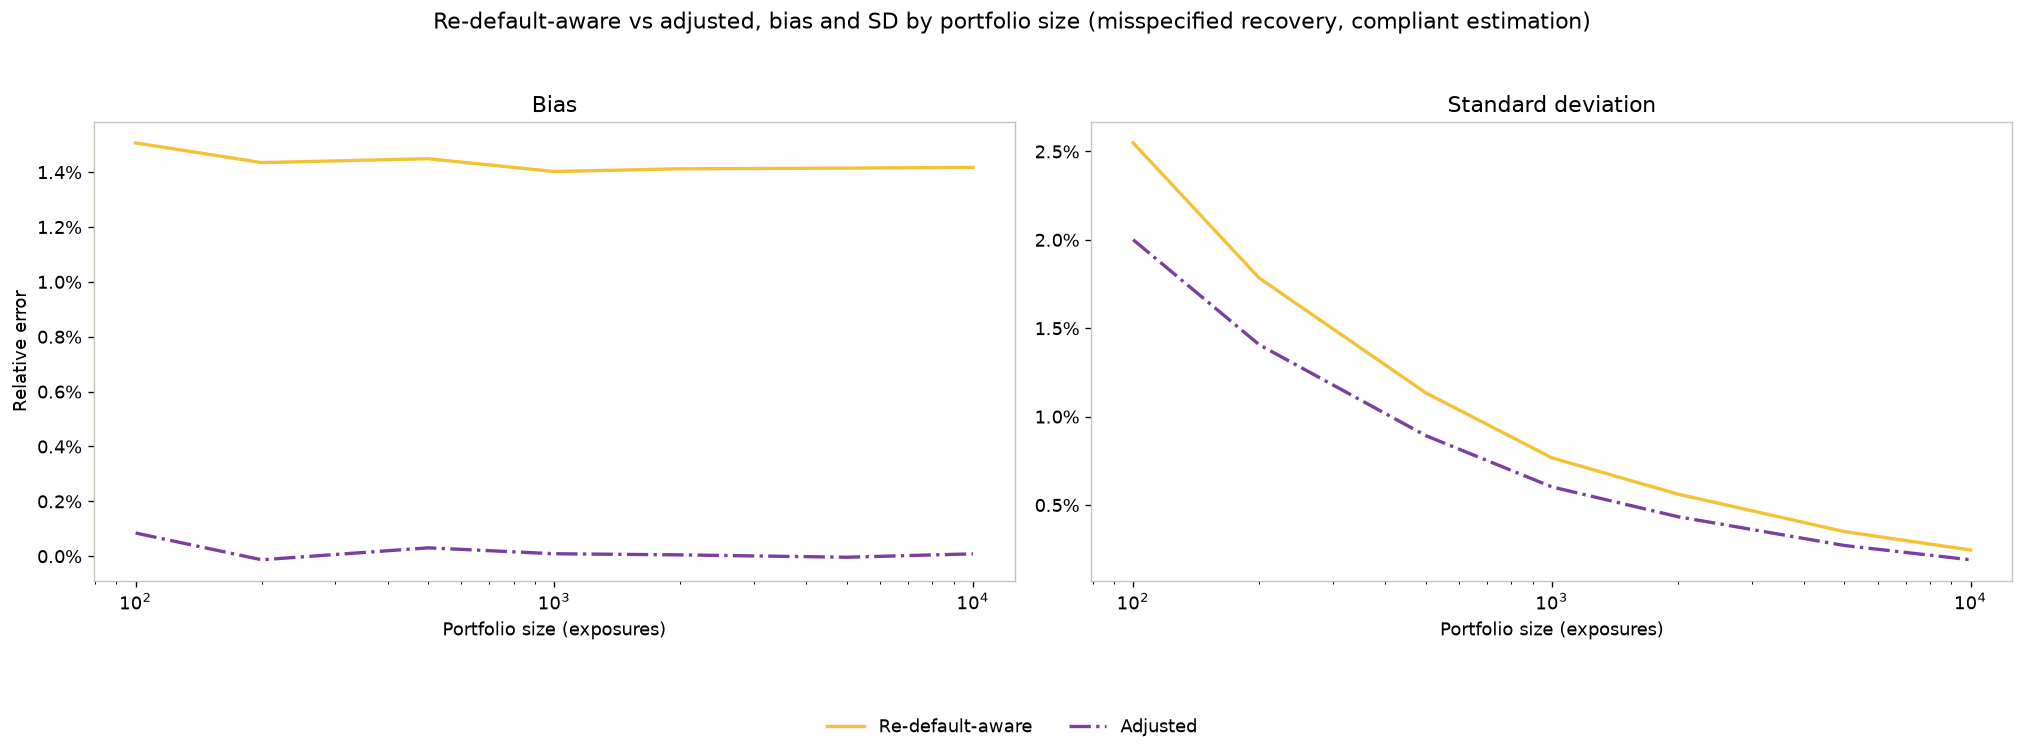

In [9]:
fig = plot_adjustment_bias_variance_decomposition(
    adjustment_complexity_summaries["compliant"],
    sweep_param="n_exposures",
    x_label="Portfolio size (exposures)",
    title="Re-default-aware vs adjusted, bias and SD by portfolio size (misspecified recovery, compliant estimation)",
)
fig.savefig(f"{RESULTS_DIR}/misspec_adjustment_complexity_comparison.png", bbox_inches="tight")

The segmented variant's bias stays within noise of zero at every portfolio size tested, from 100 to 10,000 exposures, under both naive and compliant estimation: it ranges from -0.01% to +0.09% naive and -0.01% to +0.08% compliant, with no trend either up or down as the portfolio shrinks. What does move with portfolio size is the standard deviation, from about 2.0% at 100 exposures down to about 0.19% at 10,000, the same shrinking-estimation-variance pattern the complexity/robustness notebook found for the four original formulas. The unmodified re-default-aware formula's own bias, by contrast, stays essentially flat around +2.4% (naive) and +1.4% (compliant) across the whole range: a structural bias from the wrong recovery assumption, not something more data averages away.

The shrinking independent-redefault pool the segmented variant's $RR_{ard}$ estimate draws from doesn't show up as a bias anywhere in this range, only as the expected estimation-variance cost of a smaller sample. A shrinkage-blended estimator would still be worth exploring for portfolios smaller than tested here, or merge fractions higher than the roughly 50% used in this stress configuration, but nothing in this range points to a hidden bias the segmented variant is quietly accumulating.

## Summary

Misspecifying $RR_{ard}$ attacks the re-default-aware formula's one load-bearing assumption directly: that the same recovery rate applies to a first default and to a redefaulted exposure's fresh loss. Once that assumption breaks, the re-default-aware formula becomes worse than the basic formula it was built to improve on, once $P_{rd}$ moves past about 0.05, though it stays well ahead of the loss-given-cure and Prd-correction formulas throughout.

The nine-month merge rule interacts with this misspecification without being asked to. Under naive estimation, the bias grows with the merge fraction. Under compliant estimation it doesn't: a merged exposure's compound recovery, dominated by the elapsed-time-dependent $RR_{brd}$ term rather than by $RR_{ard}$, joins the re-default-aware formula's pooled recovery rate and drives this bias back toward zero at high merge fractions.

Segmenting $RR$ from $RR_{ard}$ removes the bias entirely, under both naive and compliant estimation, across the full merge-fraction range tested, using the same merged-exposure crediting mechanism explained above. This holds at smaller portfolio sizes too: sweeping portfolio size at a stress configuration with a high merge fraction found the segmented variant's bias staying within noise from 100 exposures upward, under both regimes, with only the expected estimation-variance cost growing as the portfolio shrinks, not a hidden bias in the shrinking independent-redefault pool its $RR_{ard}$ estimate draws from.

Read together with the [baseline](01_baseline_sensitivity.ipynb) and [complexity](02_complexity_robustness_tradeoff.ipynb) notebooks, the re-default-aware formula's advantage is robust to how much of the portfolio experiences the effect it's built to correct for, and robust to whether the reference dataset follows the nine-month merge rule. It is not robust to a recovery-distribution assumption its own derivation names as necessary, but that failure is fully recoverable: segmenting the recovery rate the right way, crediting a merged exposure's recovery to the same pool the re-default-aware formula already credits it to, restores unbiasedness across every scenario this notebook tests, at every portfolio size tested too.